# **Naïve Bayes**

In [1]:
import pandas as pd
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes  import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from yellowbrick.classifier import ConfusionMatrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.rcParams["font.family"] = "DejaVu Sans"

## Base risco de crédito

In [2]:
base_risco_credito = pd.read_csv('../data/risco_credito.csv')
base_risco_credito

,historia,divida,garantias,renda,risco
0,ruim,alta,nenhuma,0_15,alto
1,desconhecida,alta,nenhuma,15_35,alto
2,desconhecida,baixa,nenhuma,15_35,moderado
3,desconhecida,baixa,nenhuma,acima_35,alto
4,desconhecida,baixa,nenhuma,acima_35,baixo
5,desconhecida,baixa,adequada,acima_35,baixo
6,ruim,baixa,nenhuma,0_15,alto
7,ruim,baixa,adequada,acima_35,moderado
8,boa,baixa,nenhuma,acima_35,baixo
9,boa,alta,adequada,acima_35,baixo


In [3]:
X_risco_credito = base_risco_credito.iloc[:, 0:4].values
X_risco_credito

array([['ruim', 'alta', 'nenhuma', '0_15'],
       ['desconhecida', 'alta', 'nenhuma', '15_35'],
       ['desconhecida', 'baixa', 'nenhuma', '15_35'],
       ['desconhecida', 'baixa', 'nenhuma', 'acima_35'],
       ['desconhecida', 'baixa', 'nenhuma', 'acima_35'],
       ['desconhecida', 'baixa', 'adequada', 'acima_35'],
       ['ruim', 'baixa', 'nenhuma', '0_15'],
       ['ruim', 'baixa', 'adequada', 'acima_35'],
       ['boa', 'baixa', 'nenhuma', 'acima_35'],
       ['boa', 'alta', 'adequada', 'acima_35'],
       ['boa', 'alta', 'nenhuma', '0_15'],
       ['boa', 'alta', 'nenhuma', '15_35'],
       ['boa', 'alta', 'nenhuma', 'acima_35'],
       ['ruim', 'alta', 'nenhuma', '15_35']], dtype=object)

In [4]:
y_risco_credito = base_risco_credito.iloc[:, 4].values
y_risco_credito

<StringArray>
[    'alto',     'alto', 'moderado',     'alto',    'baixo',    'baixo',
     'alto', 'moderado',    'baixo',    'baixo',     'alto', 'moderado',
    'baixo',     'alto']
Length: 14, dtype: str

In [5]:
def transformar_categoricos(X):
    X = X.copy()
    encoders = {}

    for i in range(X.shape[1]):
        coluna = X[:, i]

        if isinstance(coluna[0], str):
            le = LabelEncoder()
            X[:, i] = le.fit_transform(coluna)
            encoders[i] = le

    return X, encoders

In [6]:
X_risco_credito, encoders = transformar_categoricos(X_risco_credito)
X_risco_credito

array([[2, 0, 1, 0],
       [1, 0, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 2],
       [1, 1, 1, 2],
       [1, 1, 0, 2],
       [2, 1, 1, 0],
       [2, 1, 0, 2],
       [0, 1, 1, 2],
       [0, 0, 0, 2],
       [0, 0, 1, 0],
       [0, 0, 1, 1],
       [0, 0, 1, 2],
       [2, 0, 1, 1]], dtype=object)

In [7]:
with open('../data/risco_credito.pkl', 'wb') as f:
    pickle.dump([X_risco_credito, y_risco_credito], f)

In [8]:
naive_risco_credito = GaussianNB()

In [9]:
naive_risco_credito.fit(X_risco_credito, y_risco_credito)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [10]:
previsao = naive_risco_credito.predict([[0, 0, 1, 2], [2, 0, 0, 0]])

In [11]:
previsao

array(['baixo', 'moderado'], dtype='<U8')

In [12]:
naive_risco_credito.classes_

array(['alto', 'baixo', 'moderado'], dtype='<U8')

In [13]:
naive_risco_credito.class_count_

array([6., 5., 3.])

In [14]:
naive_risco_credito.class_prior_

array([0.42857143, 0.35714286, 0.21428571])

## Base credit data

In [15]:
with open('../data/credit.pkl', 'rb') as f:
    X_credit_train, y_credit_train, X_credit_test, y_credit_test = pickle.load(f)

In [16]:
X_credit_train.shape, y_credit_train.shape

((1500, 3), (1500,))

In [17]:
X_credit_test.shape, y_credit_test.shape

((500, 3), (500,))

In [18]:
naive_credit_data = GaussianNB()
naive_credit_data.fit(X_credit_train, y_credit_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [19]:
previsoes = naive_credit_data.predict(X_credit_test)
previsoes

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [20]:
accuracy_score(y_credit_test, previsoes)

0.938

In [21]:
confusion_matrix(y_credit_test, previsoes)

array([[428,   8],
       [ 23,  41]])

In [22]:
print(type(naive_credit_data))

<class 'sklearn.naive_bayes.GaussianNB'>


0.938

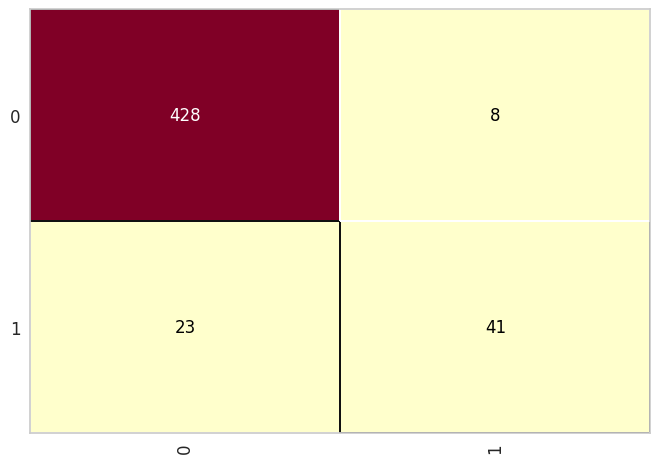

In [23]:
cm = ConfusionMatrix(naive_credit_data, force_model=True)
cm.fit(X_credit_train, y_credit_train)
cm.score(X_credit_test, y_credit_test)

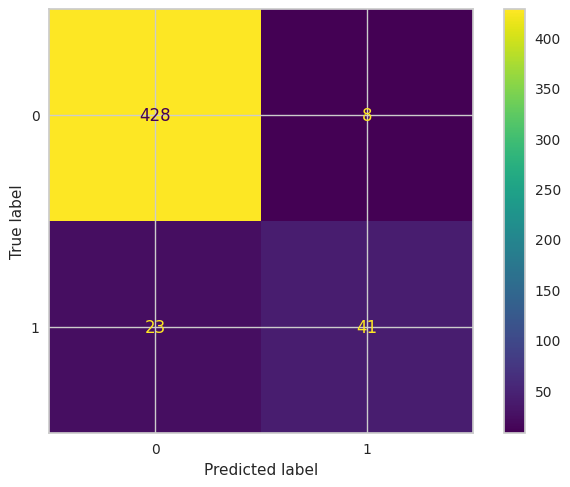

In [24]:
ConfusionMatrixDisplay.from_estimator(
    naive_credit_data,
    X_credit_test,
    y_credit_test
);

In [25]:
print(classification_report(y_credit_test, previsoes))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       436
           1       0.84      0.64      0.73        64

    accuracy                           0.94       500
   macro avg       0.89      0.81      0.85       500
weighted avg       0.93      0.94      0.93       500



## Base census

In [26]:
with open('../data/census.pkl', 'rb') as f:
    X_census_train, y_census_train, X_census_test, y_census_test = pickle.load(f)

In [27]:
X_census_train.shape, y_census_train.shape

((27676, 108), (27676,))

In [28]:
X_census_test.shape, y_census_test.shape

((4885, 108), (4885,))

In [29]:
naive_census = GaussianNB()
naive_census.fit(X_census_train, y_census_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [30]:
previsoes = naive_census.predict(X_census_test)
previsoes

array([' >50K', ' >50K', ' >50K', ..., ' <=50K', ' >50K', ' >50K'],
      shape=(4885,), dtype='<U6')

In [31]:
accuracy_score(y_census_test, previsoes)

0.4767656090071648

0.4767656090071648

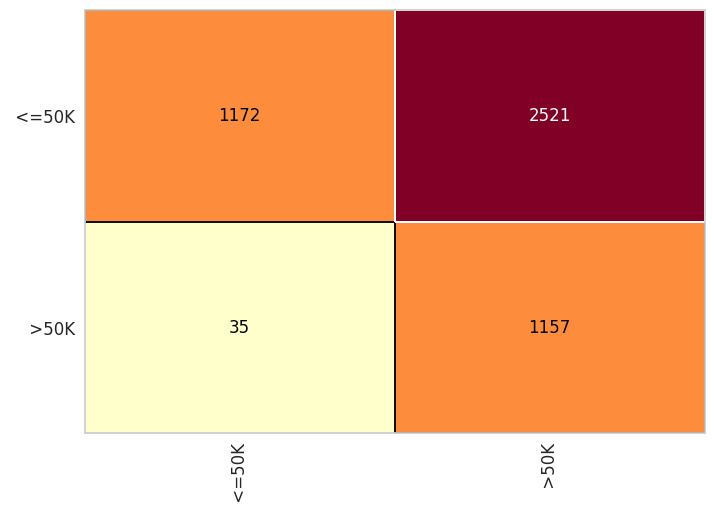

In [32]:
cm = ConfusionMatrix(naive_census, force_model=True)
cm.fit(X_census_train, y_census_train)
cm.score(X_census_test, y_census_test)

In [33]:
print(classification_report(y_census_test, previsoes))

              precision    recall  f1-score   support

       <=50K       0.97      0.32      0.48      3693
        >50K       0.31      0.97      0.48      1192

    accuracy                           0.48      4885
   macro avg       0.64      0.64      0.48      4885
weighted avg       0.81      0.48      0.48      4885

